# Lab 2 Instructions

In telecommunications, a data multiplexer typically receives input from various sources, such as multiple data terminals or sensors, and then combines these inputs into a single stream of data. This aggregated data stream can then be transmitted over a network, such as a telecommunications network or the internet, to a receiving device or destination.

Data multiplexers come in various forms and can operate at different layers of the network protocol stack. For example, a time-division multiplexer (TDM) combines data streams by allocating each input a specific time slot within a fixed time frame. Similarly, a frequency-division multiplexer (FDM) combines data streams by allocating each input a specific frequency band within the available spectrum. In this Lab you will simulate a packet voice transmission system that uses a data multiplexer that aggregates packets from several speakers and multiplexes packets to a destination device.  We will first simulate the data multplexer and analyze packets if they are voiced or not and then proceed to determine the minimum capacity that sufficiently meets the quality of service (QoS) requirements. In the following exercise we consider packet dropping probability as the target QoS specification to meet. We will then represent the data multiplexer as a Markov chain that involves modeling its behavior over time as a stochastic process where the system's state evolves through a sequence of discrete steps. 



## 1. A Packet Voice Transmission System

Suppose that a communication system is required to transmit $N$ simultaneous conversations from site A to site B using “packets” of voice information. The speech of each speaker is converted into voltage waveforms that are first digitized (i.e., converted into a sequence of binary numbers) and then bundled into packets of information that correspond to 10-millisecond (ms) segments of speech. A source and destination address is appended to each voice packet before it is transmitted. See Figure 1.

If on average the typical speaker is active only $1/3$ of the time; the rest of the time he is listening to the other party or pausing between words and phrases. The simplest design for the communication system would transmit $N$ packets every $\tau$ ms in each direction. It is known that on average about $\frac{2}{3}$ of all packets contain silence and hence no speech information. In other words, on average the $N$ speakers/sources only produce about $\frac{N}{3}$ active (non-silence) packets per $\tau$ ms period.

Let $A$ be the number of active packets produced out of a total $N$ packets generated in a given $\tau$ ms segment. The quantity $A$ takes on values in the range from $0$ (all speakers silent) to $N$ (all speakers active). If $A$ is less than or equal to the available capacity ($M$), then all the active packets are transmitted. However, if $A$ exceeds $M$, then the system is unable to transmit all the active packets, so $A - M$ of the active packets are selected at random and discarded. The discarding of active packets results in the loss of speech, so we would like to keep the fraction of discarded active packets at a level that the speakers do not find objectionable.

First consider the relative frequencies of $A$. Suppose the above experiment is repeated $n$ times. Let $A(j)$ be the outcome in the $j$ th trial. Let $N_k$ be the number of trials in which the number of active packets is $k$. The relative frequency of the outcome $k$ in the first $n$ trials is then:
$$ f^n_k = \frac{N_k}{n} $$
which we suppose converges to a probability:
$$ \lim_{n\to\infty} f^n_k = p_k, \text{ for } k = 0, 1, 2, \ldots, N $$
where $A = M = \frac{N}{3}$.
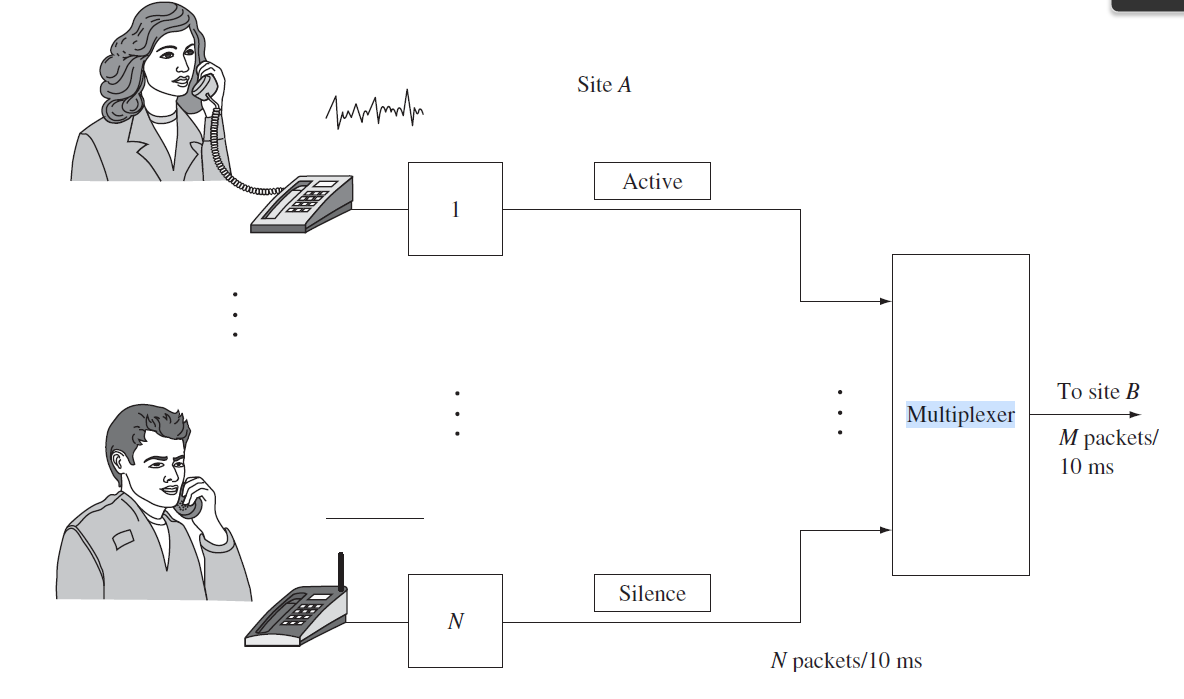

### Exercise-1
<!-- <font color='red'> -->
**1. Identify Required Inputs:**
Before diving into the code, make sure you're clear on what inputs are needed for the Voice Packet Python code. List the necessary inputs you provided in the code for

- the number of speakers (which we'll denote as $N$): 48
- the probability of a speech packet ($p_k$): 1/3
- Total number of trials $n$ 100000
- What are the inputs and outputs of np.random.binomial?  
    The inputs are n (the number of trials per draw), p (probability of success on each trial), and size (the number of draws and also shape of the output)

**2. Complete Code for Histogram Generation:**
Now, let's focus on the code. Your next task is to complete the code to generate a histogram. This histogram will display the probabilities associated with different numbers of active speakers within a group of $N=48$.

DONE

**3. Label and Explain the Histogram:**
Once you've generated the histogram, it's important to ensure it's easy to interpret. Take the time to label the axes clearly and provide an explanation of what the histogram reveals about the data.

Axes are already labelled? Why does the labs keep asking us to do things that are already done for us?  
The histogram reveals how many packets are active in each timestep. Each trial in this case is like a time step, and in each timestep we do a binomial to see how many of the 48 users are active in each timestep. The histogram shows us that there is is on average ~16 users active ine ach timestep, and that the number of active users is normally distributed.

**4. Determine Average Number of Speech Packets:**
With the histogram in hand, let's analyze it. From the plot, can you estimate, on average, how many packets on an average are marked as speech within a given $\tau = 10$ ms time segment? 

Visually, it looks like there is approx 16 users active on average in each time segment.

**5. Analytical Calculation of Average Active Packets:**
Now, let's switch gears and use an analytical approach. Your goal is to calculate the average number of active packets within the group of 48 packets generated in a $\tau = 10$ ms time segment. Utilize the formula $$\sum_{k=0}^{48} k \cdot p_k$$ for this calculation you can use python to calculate this for you (Hint: result = np.sum(np.arange(49) * fk)) Once done, compare this calculated number with the observation from the histogram. Is it the same?

The calculated value is 15.9987. So yes, they match.

**6. Extension: Calculate Average Silence Packets:**
Finally, let's extend your code to include calculations for the average number of packets that carry silence. This additional analysis will provide a more comprehensive understanding of your data. Would you like guidance on implementing this extension? (Hint: In any given trial if x number of packets are marked as speech then, $N-x = y$ packets carry silence).


- silence_packets_counts  = np.random.binomial(n=n_speakers, p=2/3, size=n_trials)
- Nk = np.bincount(silence_packets_counts)
- silence_packets_count = np.sum(Nk)
- fk1 = Nk / n_trials


**7. Generate Histogram for Silent Speakers:**
Now, generate the histogram to display the probabilities associated with different numbers of silent speakers (time segment carries silence) within a group of $N = 48$. 
- How many packets on an average carry no speech information?  
On average, 32 packets carry no speech information, or simply 48 - 16 packets
<!-- </font> -->



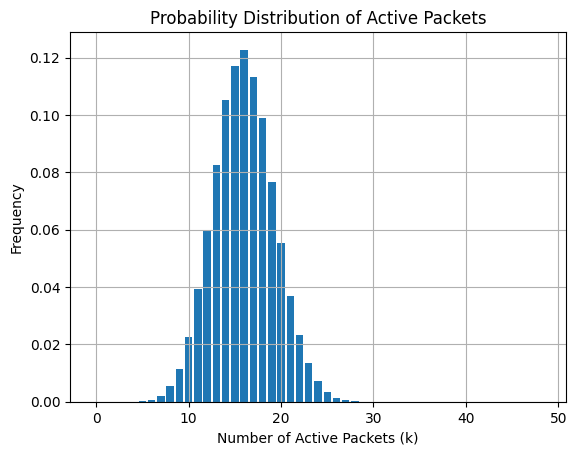

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Take user inputs for parameters
n_trials = 100000
n_speakers = 48  # Number of speakers
p = 1/3  # Probability of each speaker being active
# Simulate the experiment n_trials times
active_packets_counts = np.random.binomial(n=n_speakers, p=p, size=n_trials)

# Count the number of trials with each count of active packets
Nk = np.bincount(active_packets_counts, minlength=n_speakers+1)

# Calculate relative frequencies and convert to probabilities
fk = Nk / n_trials

# Plot histogram
plt.bar(range(len(fk)), fk)
plt.xlabel('Number of Active Packets (k)')
plt.ylabel('Frequency')
plt.title('Probability Distribution of Active Packets')
plt.grid(True)
plt.show()


In [ ]:
####Use this cell to check outputs and write code

# np.mean(Nk)

result = np.sum(np.arange(49) * fk)
print("Expected value (E[X]):", result)

Expected value (E[X]): 15.998719999999999


In [3]:
# Calculate the expected number of active packets (E[A])
E_A = np.mean(active_packets_counts)

print("The average approaches:", E_A)
max_index = np.argmax(Nk)
print("Index corresponding to the maximum probability of active users in a given 10ms time segement = ",max_index)

The average approaches: 15.99884
Index corresponding to the maximum probability of active users in a given 10ms time segement =  16


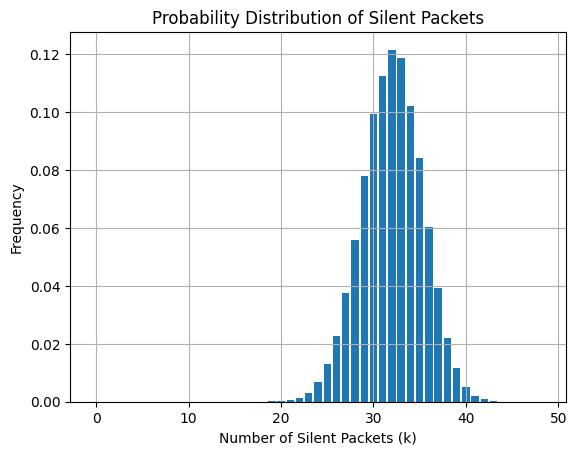

Expected number of silent packets (E[S]): 32.00095
Expected value (E[X]): 32.00095


In [ ]:
## Write the Code plotting the histogram of packets that are marked silent. 


# Simulate the experiment n_trials times
silent_packets_counts = np.random.binomial(n=n_speakers, p=2/3, size=n_trials)

# Count the number of trials with each count of active packets
Nk1 = np.bincount(silent_packets_counts, minlength=n_speakers+1)

# Calculate relative frequencies and convert to probabilities
fk1 = Nk1 / n_trials

# Plot histogram
plt.bar(range(len(fk1)), fk1)
plt.xlabel('Number of Silent Packets (k)')
plt.ylabel('Frequency')
plt.title('Probability Distribution of Silent Packets')
plt.grid(True)
plt.show()


# Calculate the expected number of silent packets (E[S])
E_S = np.mean(silent_packets_counts)
print("Expected number of silent packets (E[S]):", E_S)

result = np.sum(np.arange(49) * fk1)
print("Expected value (E[X]):", result)

### Exercise 2
<!-- <font color='red'> -->


In this code, we determine the minimum Multiplexer capacity required to achieve a packet dropping probability threshold of 1 percent, considering that in voice communications, this criteria is commonly used due to the redundancy present in speech.

1. In the code below choose a large number of n_trails= 10000 and n_speakers equals N=48. DONE
2. For the multiplexer input transmission rate, choose M = 1,10,20. DONE
3. Based on the results, recommend a value for M that satisfies the packet dropping probability threshold of 1 percent  
    M = 20 is very close, but not quite. We need to step up to M=21.



In [46]:
import numpy as np
import matplotlib.pyplot as plt

# Take user inputs for parameters
n_trials = 10000  # Number of trials
n_speakers = 48  # Number of speakers
M = [1, 10, 20]  # Transmission rate of the Multiplexer is number of packets /10msec time slots
p = 1/3  # Probability of each speaker being active 

# Simulate the experiment n_trials times
active_packets_counts = np.random.binomial(n=n_speakers, p=p, size=n_trials)

# Count the number of trials with each count of active packets
Nk = np.bincount(active_packets_counts, minlength=n_speakers+1)
# Calculate the average number of active packets
average_active_packets = np.mean(active_packets_counts)
print("Mean Number of packets marked as voiced (carry speech) E[X]:", average_active_packets)




Mean Number of packets marked as voiced (carry speech) E[X]: 16.0545


4. Calculate the total number of packets discarded every 10msec if the input rate is M = 20. 
The total number of discarded packets in 48 speaker group is calculated as $$E[Z] = \sum_{k= 20} ^{48} (k-20) \binom{48}{k} {\left({\frac{1}{3}}\right)}^k {\left({\frac{2}{3}}\right)}^{(48-k)}$$ 
5. Now set a constraint on packet drop rate in other words, the QoS for this application requires a packet dropping probability less than 1e-6  
Why do you keep changing your mind? First it's a 1% requirement, now 1e-6, then 1% again in Q7????
6. Summarize the operation of a Multiplexer required transmission rate based on your results from this exercise.

In [49]:
import math

# Define the constants
p = 1/3
p_dash = 1-p # probability of a packet generated carries no speech or inactive packet
n = 48  # Number of speakers


for M in [1, 10, 20, 21]:  # Transmission rate of the Multiplexer is number of packets /10msec time slots
    print("\nFor M =", M)
    # Define the summation range
    start_k = M  # Start from M since we are interested in the number of packets discarded when the number of active packets exceeds M
    end_k = n

    # Initialize the sum
    total_sum = 0

    # Perform the summation
    for k in range(start_k, end_k + 1):
        binomial_coefficient = math.comb(n, k)
        term = (k - M) * binomial_coefficient * (p ** k) * (p_dash ** (n - k))
        total_sum += term

    print("Total number of packets discarded ", float(total_sum))
    # average_active_packets = float(input("Average number of active packets"))
    print("Percentage of active packets discarded ", (total_sum/average_active_packets) * 100, "%")
    # Define dropping probability threshold
    # dropping_probability_threshold = float(input("Input dropping probability threshold: ")) # Quality of service (QoS) threshold 

    



For M = 1
Total number of packets discarded  15.00000000352878
Percentage of active packets discarded  93.4317481299871 %

For M = 10
Total number of packets discarded  6.032021261102588
Percentage of active packets discarded  37.57215273663202 %

For M = 20
Total number of packets discarded  0.18163953295146243
Percentage of active packets discarded  1.1313932726118061 %

For M = 21
Total number of packets discarded  0.09563597548589652
Percentage of active packets discarded  0.5956957581107882 %


<!-- <font color='red'> -->
7. Is the percentage of active packets discarded acceptable for a 1 percent QoS requirement?   

    Technically not for M=20, as 1.13% of packets get discarded. If we step up to M=21, then it is 0.59%, which satisfies the QoS requirement.
 <!-- </font>    -->


## 2. Data Multiplexer as Discrete-time Markov Chain

Recall from lectures discussion on *discrete-time Markov chains*. It is a stochastic process that evolves through a sequence of discrete time steps, where the future state of the system only depends on its current state and not on its past history beyond that current state. You can capture the behavior of the data multiplexer over time by simulating it as a discrete-time Markov chain. Representing a data multiplexer as a Markov chain involves modeling its behavior over time as a stochastic process where the system's state evolves through a sequence of discrete steps. In this context, the state of the multiplexer typically refers to the number of packets in its buffer or the occupancy of its channels.

In the case of the data multiplexer, the system evolves in discrete time steps. At each time step, the number of packets in the buffer (the system's state) changes according to the given transition probabilities, but the transition to the next state only depends on the current state of the system, not on its past history. This property is known as the **Markov property**.

Specifically, in the data multiplexer scenario:
- The system's state at time $t$ (the number of packets in the buffer) is represented by the variable $N$.
- At each time step, the system transitions from one state to another based on the defined transition probabilities.
- The transition probabilities specify the likelihood of moving from the current state $N$ to the next state $N+1$, and these  probabilities are independent of the system's previous states or the history of its transitions.
- The system evolves in discrete time steps, where the transition probabilities determine the future state of the system based solely on its current state.

Therefore, because the system evolves in discrete time steps and satisfies the Markov property, it is considered a discrete-time Markov chain.

Note that the Markov chain is similar to that of a birth-death process except that transitions from a state to itself are allowed.

## States of Data Multiplexer
The conditions for the transition probabilities in the Markov chain for the data multiplexer are described as follows:

**1. Initial State (N = 0):**
   - If the system is empty (N = 0), the next state can either remain empty with probability $(1 - a)$ or transition to having one packet with probability $a$. Also, let's denote the probability that a packet is serviced and transmitted out as $b$. Each serviced packet results in a decrease in the state of the system by 1.
   - Transition probabilities: $p_{00} = 1 - a$, $p_{01} = a$.

**2. States with Non-zero Packets (N > 0):**
If the system has one or more packets (N > 0) and a packet arrives at its buffer, then there are 3 possibilities, one where the packet is serviced and transmitted out with a transition probability $b$, packet is not serviced $(1-a)$ and then the packet stays in the buffer and increases the system state from N to N+1.  The next state can change as follows:

- If the next state is one less than the current state (N - 1), the transition probability is $$b(1 - a)$$ Here, $b$ represents the probability of successfully transmitting a packet, and $(1 - a)$ represents the probability that a packet arrives but is not serviced (not transmitted).
- If the next state remains the same (N), it means that neither a packet is transmitted out nor a new packet arrives. the transition probability is packet arrives but not transmitted out plus no packet arrives and not transmitted $$a \cdot b + (1 - a) \cdot (1 - b)$$ 
- If the next state is one more than the current state (N + 1), the transition probability is $$(1 - b) \cdot a$$. Here, $(1 - b)$ represents the probability that a packet arrives but is not transmitted, and $a$ represents the probability of a new packet arrival.
- To summarise, the Transition probabilities are as follows:
  - $p_{n,n-1} = b \cdot (1 - a)$
  - $p_{nn} = a \cdot b + (1 - a) \cdot (1 - b)$
  - $p_{n,n+1} = (1 - b) \cdot a$

**3. Final State (N = $N_{\text{max}}$):**
 If the system reaches the maximum state (N = $N_{\text{max}}$), the next state can transition as follows:
- If the next state is one less than the maximum state ($N_{\text{max}}$ - 1), the transition probability is $(1 - a) \cdot b$.
- If the next state remains the same ($N_{\text{max}}$), the transition probability is $1 - b$.
- Transition probabilities:
  - $p_{N_{\text{max}}, N_{\text{max}} - 1} = (1 - b) \cdot (1 - a)$
  - $p_{N_{\text{max}}, N_{\text{max}}} = (1 - a) \cdot b$


  - $p_{N_{\text{max}}, N_{\text{max}} - 1} = (1 - a) \cdot b$
  - $p_{N_{\text{max}}, N_{\text{max}}} = (1 - b) \cdot (1 - a)$

These conditions define how the state of the data multiplexer changes over time according to the given transition probabilities and are summarized in Table.





| **n**      | **n+1**       | **pₙ,ₙ₊₁** | **Comment**                               |
|------------|---------------|-------------|--------------------------------------------|
| 0          | 0             |             | No packet arrival                          |
| 0          | 1             |             | Packet arrival                             |
| 1          | 0             |             | Packet transmission                        |
| 1          | 1             |             | Packet arrival and no transmission         |
| 1          | 2             |             | Packet arrival and transmission            |
| 2          | 1             |             | Packet transmission                        |
| 2          | 2             |             | Packet arrival and no transmission         |
| 2          | 3             |             | Packet arrival and transmission            |
| 3          | 2             |             | Packet transmission                        |
| 3          | 3             |             | Packet arrival and no transmission         |
| 3          | 4             |             | Packet arrival and transmission            |
| …          | …             | …           | …                                          |
| Nₘₐₓ      | Nₘₐₓ          |             | No packet arrival and transmission         |
| Nₘₐₓ      | Nₘₐₓ - 1      |             | No packet arrival but a packet is transmitted |



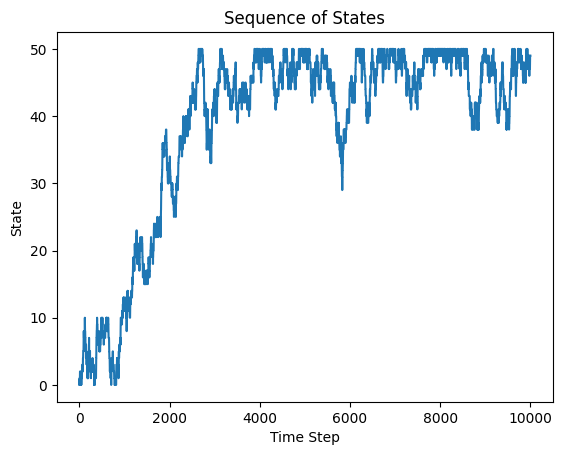

In [68]:
import numpy as np
import matplotlib.pyplot as plt

# Function to simulate a discrete Markov chain
def Discrete_MC(Nmax, P, IC, L):
    # Initialize an array to store the sequence of states. 
    #L denotes the number of events 
    stseq = np.zeros(L)
    # Define the states
    s = np.arange(1, Nmax + 2)
   
    # Define possible state transitions
    step = [-1, 0, 1]
    # Choose initial state based on initial conditions
    InitSt = np.random.choice(s, p=IC)
  
    stseq[0] = InitSt
    # Generate the sequence of states
    for n in range(1, L):
        currentst= stseq[n - 1]
        nextst = currentst + np.random.choice(step, p=P[int(stseq[n - 1]) - 1])
        stseq[n] = nextst
    return stseq

# User inputs for parameters
# Nmax = int(input("Enter the maximum state of the system (Nmax): "))
# a = float(input("Enter the probability of packet arrival (a) packets/sec: "))
# b = float(input("Enter the probability of packet transmission (b) packets/sec: "))
Nmax = 50
a = 0.15
b = 0.13

# Define transition probabilities
P = np.zeros((Nmax + 1, 3))
#for N=0 state 0 buffer is empty
P[0, :] = [0, 1 - a, a]
r = [b * (1-a), a * b + (1 - a) * (1 - b), (1 - b) * a]
#for N>0
for n in range(1, Nmax):
    P[n, :] = r
P[Nmax, :] = [(1 - a) * b, 1 - (1 - a) * b, 0]

# Initial conditions
IC = np.zeros(Nmax + 1)
IC[0] = 1

# Number of Events 
# L = int(input("Enter the number of events (L): "))
L = 10000

# Simulate the Markov chain
Seq = Discrete_MC(Nmax, P, IC, L)
# Plot the sequence of states
plt.plot(Seq - 1)
plt.title('Sequence of States')
plt.xlabel('Time Step')
plt.ylabel('State')
plt.show()


### **Exercise-3**
A  template for the Markov chain simulation of a Data Multiplexer is provided. Use this template and complete the following steps:    
1. Examine the Python function definition in the code template. How many input parameters are needed for this function? And   what is the expected output of this function?  

4 input parameters are required: Nmax (the max state of the system), P (the transition probability matrix), IC (the initial conditions), and L (the number of steps to simulate). The function returns stseq, which is an array of length L, with each elemnt representing the state of the system in each timestep.

2. step = [-1, 0, 1]. This vector parameter has three numbers. What does it indicate? Explain.

This represents the possible state changes. One down, one up, or stay the same.

3. Explain why the initial conditions are as defined in P[0, :] = [0, 1 - a, a]? Specifically what does 0, 1-a and a indicate?  

This represents the transition probabilities in the minimum state. The 0 is the probability of going to a lower state (not possible, no packets to service), 1-a is the probability of staying in the minimum state (no packets arriving), and then a is the probability of moving up a state (1 packet arrives).

4. Run the code and provide appropriate inputs for number of ststes Nmax = int(input("Enter the maximum state of the system (Nmax): ")), a and b. Choose an observation window/ number of trials L = 10000. 

I chose Nmax = 50, a = 0.15 and b = 0.13, and L = 10000  
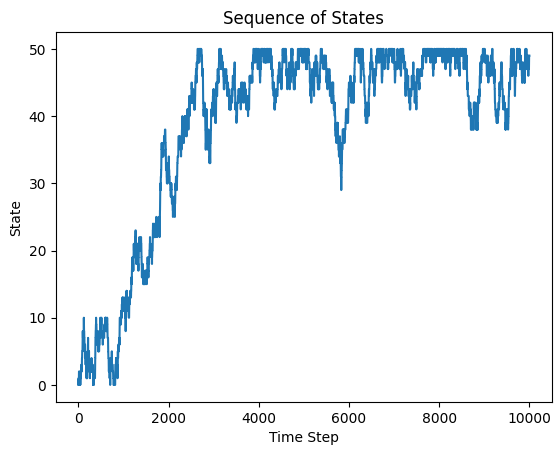

5. Explain the evolution of states of the Markov chain. Explain x-axis and y-axis of the plot displayed. 



6. For a = 0.9 and b= 0.2 is the Markov chain stable? why is it so?



7. What value for arrival rate a relative to processing rate (transmission rate) is the Markov chain stable? Specially simulate cases $a=b$, $a>b$ and $a<b$ to explain this requirement.     






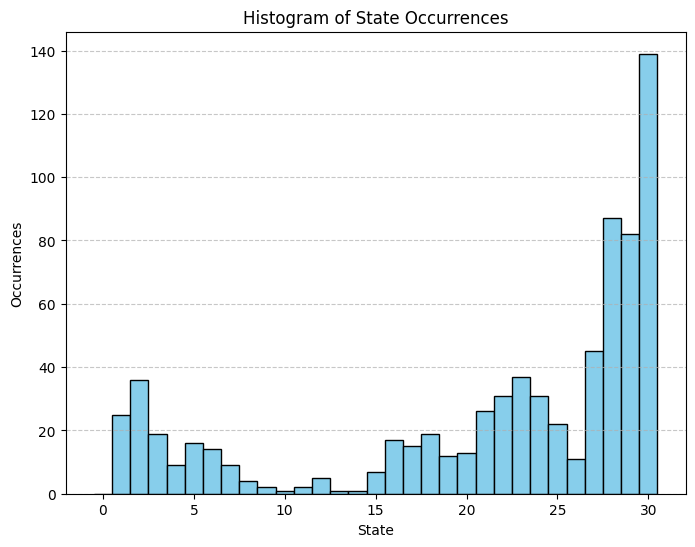

In [57]:

# Plot histogram of state occurrences
plt.figure(figsize=(8, 6))
plt.hist(Seq, bins=np.arange(Nmax + 2) - 0.5, color='skyblue', edgecolor='black')
plt.title('Histogram of State Occurrences')
plt.xlabel('State')
plt.ylabel('Occurrences')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

8. plot the histogram using the above code snippet and explain

In [5]:
np.var(Seq)

41.096999

## Extra credit- Complete Task 4 of Workshop

- A data communication line delivers a block every 10 μs.
- A decoder checks each block and corrects errors if necessary.
- Error checking time: 1 μs per block.
- Error correction time:
  - No error: 0 μs
  - One error: 5 μs
  - More than one error: 20 μs
- If the decoder is busy, incoming blocks are queued.
- Initially, the decoder is empty.
- Number of errors in the first 10 blocks:  
**Questions:**
1. Plot the number of blocks in the decoder as a function of time.  
2. Find the mean number of blocks in the decoder.  
3. What percentage of the time is the decoder empty?  

---

## Decoder Timing Table

| **Block** | **Errors** | **Arrival Time (μs)** | **Departure Time (μs)** |
|-----------|------------|------------------------|--------------------------|
| 1         | 0          | 10                     |                          |
| 2         | 1          | 20                     |                          |
| 3         | 3          | 30                     |                          |
| 4         | 1          | 40                     |                          |
| 5         | 0          | 50                     |                          |
| 6         | 4          | 60                     |                          |
| 7         | 0          | 70                     |                          |
| 8         | 1          | 80                     |                          |
| 9         | 0          | 90                     |                          |
| 10        | 0          | 100                    |                          |

*Table: Arrival and Departure Times for Each Block (starting at 10 μs)*

In [ ]:
import matplotlib.pyplot as plt

# Parameters
arrival_interval = 10  # µs
check_time = 1         # µs
error_correction = {0: 0, 1: 5, "more": 20}  # µs



# Arrival times
arrival_times = [          ] 
# Errors in the first 10 blocks
errors = [0, 1, 3, 1, 0, 4, 0, 1, 0, 0]

# Events
events = []  # (time, type, block_id)
decoder_free_time = 0

queue = []
departures = []

for i, err in enumerate(errors):
    arrival = arrival_times[i]
    events.append((arrival, "A", i+1))  # record arrival
    
    # Decide when this block will leave
    if err == 0:
        service_time = check_time + error_correction[0]
    elif err == 1:
        service_time = check_time + error_correction[1]
    else:
        service_time = check_time + error_correction["more"]

    start_time = max(arrival, decoder_free_time)
    finish_time = start_time + service_time
    decoder_free_time = finish_time
    events.append((finish_time, "D", i+1))  # record departure

# Sort events in chronological order
events.sort()

# Now track number of blocks over time
time_points = []
block_counts = []
current_blocks = 0

for t, etype, bid in events:
    if etype == "A":
        current_blocks += 1
    else:  # "D"
        current_blocks -= 1
    time_points.append(t)
    block_counts.append(current_blocks)

# Plot
plt.step(time_points, block_counts, where='post', color='b', label="Number of Blocks in Decoder")

# Add labels for arrivals and departures (simpler)
current_blocks = 0
for t, etype, bid in events:
    if etype == "A":
        current_blocks += 1
        plt.text(t, current_blocks, f"A{bid}", color='g', fontsize=8,
                 ha='center', va='bottom')
        plt.axvline(t, color='g', linestyle='--', alpha=0.5)
    else:  # Departure
        plt.text(t, current_blocks, f"D{bid}", color='r', fontsize=8,
                 ha='center', va='top')
        plt.axvline(t, color='r', linestyle='--', alpha=0.5)
        current_blocks -= 1

plt.xlabel("Time (µs)")
plt.ylabel("Number of Blocks")
plt.title("Number of Blocks in Decoder over Time")
plt.legend()
plt.grid(True)
plt.show()
